# Actividad 3 · Calibración de hiperparámetros con pipelines de scikit-learn

**Curso:** Machine Learning Engineering (MLE / MLOps) — Universidad del Valle de Guatemala
**Estudiante:** Diego Linares (`lin221256@uvg.edu.gt`) — entrega individual
**Repositorio:** <https://github.com/DiegoLinares11/Actividad3-MLOPS>
**Dataset:** `champions_league_matches.csv` — UEFA Champions League 2025/26, el mismo del Ejercicio 1

---

## Qué se investiga aquí

Los objetos del pipeline de scikit-learn que permiten **calibrar hiperparámetros**:

| Objeto | Para qué sirve |
|---|---|
| `Pipeline` | Encadena pasos con nombre y expone sus hiperparámetros como `paso__hiperparametro`. |
| `ColumnTransformer` | Aplica un tratamiento distinto a cada grupo de columnas; se anida un nivel más. |
| `SelectKBest` | Selección de variables **calibrable** (su `k` se optimiza junto al modelo). |
| `StratifiedKFold` | Validación cruzada que respeta la proporción de las tres clases. |
| `GridSearchCV` | Búsqueda exhaustiva sobre una rejilla. |
| `RandomizedSearchCV` | Muestreo aleatorio; permite comparar **familias de modelos** distintas. |
| `HalvingGridSearchCV` | Mitades sucesivas: mismo espacio, mucho menos cómputo. |
| `validation_curve` / `learning_curve` | Diagnóstico de sobreajuste y de falta de datos. |
| `permutation_importance` | Qué variables sostienen realmente al modelo. |

## Cómo se mapea a CRISP-DM

Esta actividad se para en las etapas de **Modeling** y **Evaluation**; las anteriores
(Business/Data Understanding y Data Preparation) vienen del Ejercicio 1 y de la Actividad 1 y aquí
solo se recapitulan.

```
Business Understanding ─┐
Data Understanding      ├── Ejercicio 1
Data Preparation ───────┘   Actividad 1  (pipeline de preparación)
Modeling ───────────────┐
Evaluation              ├── Actividad 3  ← este notebook
Deployment (empaquetado)┘
```

## 0. Entorno

In [1]:
import platform, socket, sys, time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

import act3_pipeline

print("Equipo    :", socket.gethostname())
print("Sistema   :", platform.system(), platform.release())
print("Python    :", platform.python_version())
print("sklearn   :", sklearn.__version__)
print("pandas    :", pd.__version__)
print("act3_pipeline:", act3_pipeline.__version__)

Equipo    : Dlinares
Sistema   : Windows 11
Python    : 3.14.2
sklearn   : 1.8.0
pandas    : 2.3.3
act3_pipeline: 0.1.0


## 1. Recapitulación: Business Understanding y Data Understanding

**Problema.** Clasificar el resultado de un partido de Champions League en tres clases:
`Home Win`, `Away Win` o `Draw`, a partir de las estadísticas de juego (posesión, tiros a puerta,
atajadas y los equipos que se enfrentan).

**Criterio de éxito.** Superar de forma clara a un modelo tonto que siempre prediga la clase
mayoritaria (victoria local).

**Lo que ya sabíamos del dataset (Ejercicio 1):**

- 151 filas en crudo, de las cuales **7 están vacías** (separan jornadas) → quedan 144 partidos.
- Columnas numéricas guardadas como texto: `'63%'` y `'3 of 10'`.
- `score` y `winner` son **fuga de información** (revelan el resultado) → se descartan.
- Nulos en `home_saves_pct` (casos de "0 of 0").
- Clases desbalanceadas: Home Win 71, Away Win 48, **Draw solo 25**.

Ese desbalance es la razón de una decisión central de esta actividad: **la métrica que se optimiza
durante la calibración es `f1_macro`, no `accuracy`**. El `accuracy` premia acertar la clase
mayoritaria; `f1_macro` pesa igual a las tres clases y obliga al modelo a tomarse en serio los
empates.

In [2]:
from act3_pipeline import cargar_datos, extraer_datos, filtrar_datos

crudo = extraer_datos()
limpio = filtrar_datos(crudo)
X_train, X_test, y_train, y_test = cargar_datos()   # 80/20 estratificado, seed=42

print(f"CSV crudo  : {crudo.shape[0]} filas x {crudo.shape[1]} columnas")
print(f"Filtrado   : {limpio.shape[0]} partidos x {limpio.shape[1]} columnas")
print(f"Separación : train={len(X_train)}  test={len(X_test)}")
print()
print("Distribución de clases (entrenamiento):")
print(y_train.value_counts().to_string())

CSV crudo  : 151 filas x 18 columnas
Filtrado   : 144 partidos x 13 columnas
Separación : train=115  test=29

Distribución de clases (entrenamiento):
result
Home Win    57
Away Win    38
Draw        20


El conjunto de prueba (29 partidos) se guarda bajo llave: **no participa en la calibración**.
Todo el ajuste de hiperparámetros se hace con validación cruzada dentro de los 115 partidos de
entrenamiento, y el test se abre una sola vez, en la etapa de Evaluation.

## 2. El pipeline y su diagrama

`sklearn.set_config(display="diagram")` cambia la representación de cualquier estimador en Jupyter:
en vez de texto, muestra un **diagrama interactivo** en el que se puede hacer clic en cada bloque
para ver sus parámetros.

In [3]:
from sklearn import set_config
from act3_pipeline import construir_pipeline

set_config(display="diagram")

pipe = construir_pipeline()
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('seleccion', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('porcentajes', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output 

### 2.1 De dónde salen los nombres de los hiperparámetros

El pipeline expone **todos** sus parámetros con `get_params()`, usando `__` para bajar de nivel.
Esa es la llave que van a usar `GridSearchCV` y `RandomizedSearchCV`.

In [4]:
from act3_pipeline import nombres_de_hiperparametros

llaves = nombres_de_hiperparametros(pipe)
print(f"El pipeline expone {len(llaves)} parámetros calibrables. Algunos ejemplos:\n")
for k in [
    "preprocesamiento__numericas__imputar__strategy",
    "preprocesamiento__categoricas__onehot__handle_unknown",
    "seleccion__k",
    "modelo__n_estimators",
    "modelo__max_depth",
    "modelo",                      # ¡el modelo entero es un hiperparámetro más!
]:
    print(f"  {k:<55} -> {pipe.get_params()[k]}")

El pipeline expone 107 parámetros calibrables. Algunos ejemplos:

  preprocesamiento__numericas__imputar__strategy          -> median
  preprocesamiento__categoricas__onehot__handle_unknown   -> ignore
  seleccion__k                                            -> all
  modelo__n_estimators                                    -> 300
  modelo__max_depth                                       -> None
  modelo                                                  -> RandomForestClassifier(n_estimators=300, random_state=42)


El detalle importante: **`modelo` también es un parámetro**. Eso es lo que permite, más adelante,
poner cuatro familias de clasificadores distintas dentro de una sola búsqueda.

### 2.2 Cuántas columnas entran y cuántas salen

In [5]:
prep = pipe.named_steps["preprocesamiento"]
Xt = prep.fit_transform(X_train)
print(f"Entran  : {X_train.shape[1]} columnas crudas")
print(f"Salen   : {Xt.shape[1]} columnas numéricas hacia el modelo")
print()
print("Primeros nombres generados:", list(prep.get_feature_names_out()[:8]))

Entran  : 12 columnas crudas
Salen   : 86 columnas numéricas hacia el modelo

Primeros nombres generados: ['numericas__home_shots_on_target_pct', 'numericas__away_shots_on_target_pct', 'numericas__home_saves_pct', 'numericas__away_saves_pct', 'porcentajes__home_possession_pct', 'porcentajes__away_possession_pct', 'razones__home_shots_on_target_hechos', 'razones__home_shots_on_target_intentos']


De 12 columnas crudas salen 86 numéricas (las 72 del One-Hot de los equipos pesan casi todo).
Con solo 115 partidos de entrenamiento, 86 variables son demasiadas: por eso el pipeline incluye
`SelectKBest`, y **cuántas variables conservar (`k`) se decide calibrando**, no a ojo.

---

# 3. Modeling (CRISP-DM)

## 3.1 Punto de partida: el pipeline sin calibrar

Antes de calibrar hay que saber contra qué se compara. Este es el pipeline con los valores por
defecto, evaluado con la misma validación cruzada que usará la búsqueda.

In [6]:
from sklearn.model_selection import cross_val_score
from act3_pipeline import CV, SCORING

base_scores = cross_val_score(construir_pipeline(), X_train, y_train, cv=CV, scoring=SCORING)
print(f"Pipeline sin calibrar — {SCORING} en CV: {base_scores.mean():.3f} (+/- {base_scores.std():.3f})")
print("Por fold:", np.round(base_scores, 3))

Pipeline sin calibrar — f1_macro en CV: 0.508 (+/- 0.037)
Por fold: [0.506 0.495 0.46  0.505 0.574]


## 3.2 ¿Por qué **estos** hiperparámetros? (y no otros)

Calibrar no es tirar todo a una rejilla a ver qué pega: cada combinación extra multiplica el
cómputo, y meter parámetros que no importan solo agrega ruido y riesgo de sobreajustar la propia
búsqueda. Un hiperparámetro entra a la rejilla cuando cumple tres condiciones:

1. **Controla la capacidad del modelo** (el equilibrio sesgo–varianza), que es el problema real de
   este dataset: 115 partidos de entrenamiento contra 86 columnas de entrada.
2. **Su valor correcto no se puede deducir** de la teoría ni del análisis del Ejercicio 1.
3. **Interactúa con los demás** — por eso se buscan juntos y no uno por uno.

### Los seis elegidos

| Hiperparámetro | Qué controla | Por qué se calibra **en este dataset** | Qué se espera |
|---|---|---|---|
| `...imputar__strategy`<br>`median` / `mean` | Con qué valor se rellenan los nulos | Los nulos están en `home_saves_pct` / `away_saves_pct` y vienen de partidos con "0 of 0" atajadas. Es una distribución sesgada y acotada (0–100): la media se corre con los extremos, la mediana no. Son pocos nulos, así que la pregunta real es **si esta decisión importa o da igual**. | Diferencia pequeña; sirve para justificar la elección con evidencia y no por costumbre. |
| `seleccion__k`<br>15 / 30 / `all` | Cuántas de las 86 variables llegan al modelo | 72 de esas 86 columnas son el One-Hot de los equipos, y cada equipo aparece en ~6–8 partidos: son casi ruido. Con 115 filas, arrastrar 86 columnas es pedir sobreajuste. Cuántas conservar **no se puede saber de antemano**. | Que un `k` recortado le gane a `all`. |
| `modelo__n_estimators`<br>200 / 400 | Cuántos árboles promedia el bosque | Más árboles reducen la varianza del promedio y **nunca sobreajustan más**, pero cuestan tiempo. Se calibra para encontrar dónde se aplana la curva y no pagar cómputo de gratis. | Diferencia mínima: confirmar que 200 ya basta. |
| `modelo__max_depth`<br>`None` / 6 | Qué tan profundo crece cada árbol | Es **la** perilla de sobreajuste del bosque. Con 115 filas un árbol sin límite llega a hojas puras y memoriza (se ve en `mean_train_score` ≈ 1.0). Limitar la profundidad cambia varianza por sesgo. | Que la profundidad limitada cierre la brecha entre entrenamiento y validación. |
| `modelo__min_samples_leaf`<br>1 / 3 | Mínimo de partidos por hoja | La otra perilla de capacidad. Con `1`, una hoja puede sostenerse en **un solo partido raro**, y con apenas 20 empates en entrenamiento eso es justo lo que hace ruido en la clase minoritaria. | Que exigir ≥3 partidos por hoja estabilice el `f1` de `Draw`. |
| `modelo__class_weight`<br>`None` / `balanced` | Cuánto pesa equivocarse en cada clase | Respuesta directa al desbalance 57 / 38 / 20. `balanced` pondera inverso a la frecuencia, así que fallar un empate cuesta ~3× más que fallar una victoria local. Como la métrica objetivo es `f1_macro`, esto ataca el problema de frente. | Que `balanced` gane; es la hipótesis más fuerte de la rejilla. |

### Lo que **no** se calibra, y por qué

| Decisión | Por qué queda fija |
|---|---|
| `handle_unknown="ignore"` en el One-Hot | No es una perilla de desempeño: es un requisito. Si aparece un equipo que no estaba en entrenamiento, el pipeline no puede reventar. |
| `StandardScaler` en las columnas numéricas | Al Random Forest le da igual, pero la regresión logística y el SVC **lo necesitan**. Ponerlo siempre no cuesta nada. |
| La métrica (`f1_macro`) y el esquema de CV (`StratifiedKFold(5)`) | Son **decisiones de diseño** derivadas del problema (clases desbalanceadas, dataset chico), no hiperparámetros. Calibrarlas sería elegir la vara con la que uno mismo se mide. |
| `random_state=42` en todo | Reproducibilidad: es lo que permite que el resultado salga idéntico en otra computadora. |

## 3.3 `GridSearchCV`: búsqueda exhaustiva

La rejilla mezcla a propósito hiperparámetros de **preprocesamiento** y de **modelo**, porque no
son independientes: cuántas variables conservar depende de qué tan profundo sea el bosque.

2 × 3 × 2 × 2 × 2 × 2 = **96 combinaciones** × 5 folds = **480 ajustes** del pipeline completo.

> Lo que hace correcta a esta búsqueda: el preprocesamiento se reajusta **dentro de cada fold**.
> Si se hubiera imputado y escalado antes de partir los datos, la información del fold de
> validación se habría filtrado al entrenamiento y el resultado saldría inflado.

In [7]:
from act3_pipeline import busqueda_grid

grid = busqueda_grid()
grid          # el objeto de búsqueda también se dibuja como diagrama

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__class_weight': [None, 'balanced'], 'modelo__max_depth': [None, 6], 'modelo__min_samples_leaf': [1, 3], 'modelo__n_estimators': [200, 400], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more

In [8]:
t0 = time.perf_counter()
grid.fit(X_train, y_train)
t_grid = time.perf_counter() - t0

print(f"Combinaciones evaluadas : {len(grid.cv_results_['params'])}")
print(f"Tiempo                  : {t_grid:.1f} s")
print(f"Mejor {SCORING} en CV    : {grid.best_score_:.3f}")
print("\nMejores hiperparámetros:")
for k, v in sorted(grid.best_params_.items()):
    print(f"  {k:<55} = {v}")

Combinaciones evaluadas : 96
Tiempo                  : 57.5 s
Mejor f1_macro en CV    : 0.563

Mejores hiperparámetros:
  modelo__class_weight                                    = balanced
  modelo__max_depth                                       = 6
  modelo__min_samples_leaf                                = 3
  modelo__n_estimators                                    = 400
  preprocesamiento__numericas__imputar__strategy          = median
  seleccion__k                                            = 30


In [9]:
from act3_pipeline import tabla_resultados

tabla_resultados(grid, top=8)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
0,1,0.562723,0.059466,0.957079,"{'modelo__class_weight': 'balanced', 'modelo__..."
1,2,0.561805,0.059776,0.963159,"{'modelo__class_weight': 'balanced', 'modelo__..."
2,2,0.561805,0.059776,0.960394,"{'modelo__class_weight': 'balanced', 'modelo__..."
3,2,0.561805,0.059776,0.957079,"{'modelo__class_weight': 'balanced', 'modelo__..."
4,5,0.553101,0.037062,0.936174,"{'modelo__class_weight': 'balanced', 'modelo__..."
5,6,0.546042,0.059667,0.915704,"{'modelo__class_weight': 'balanced', 'modelo__..."
6,7,0.545244,0.066724,1.000000,"{'modelo__class_weight': None, 'modelo__max_de..."
7,7,0.545244,0.066724,1.000000,"{'modelo__class_weight': None, 'modelo__max_de..."


La columna `mean_train_score` frente a `mean_test_score` muestra la brecha de sobreajuste: el
bosque memoriza el entrenamiento casi perfecto (≈0.96–1.00) y en validación se queda en ~0.56. Esa
distancia es justo lo que intentan cerrar `max_depth`, `min_samples_leaf` y `k`.

### ¿Se cumplieron las hipótesis de la sección 3.2?

Agrupando los 96 resultados por el valor de cada hiperparámetro se ve cuánto mueve la aguja cada
uno. Esto es lo que convierte la calibración en un **experimento con conclusiones** y no en una
caja negra que escupe un número:

In [10]:
res = pd.DataFrame(grid.cv_results_)
for param in ["param_modelo__class_weight", "param_seleccion__k", "param_modelo__max_depth"]:
    efecto = res.groupby(param, dropna=False)["mean_test_score"].mean().round(3)
    print(f"{param}:")
    print(efecto.to_string(), "\n")

param_modelo__class_weight:
param_modelo__class_weight
balanced    0.524
NaN         0.515 

param_seleccion__k:
param_seleccion__k
15     0.523
30     0.525
all    0.509 

param_modelo__max_depth:
param_modelo__max_depth
NaN    0.522
6.0    0.516 



Lectura de los tres promedios anteriores:

- **`class_weight="balanced"` gana**, tal como se esperaba: es la respuesta directa al desbalance y
  la razón por la que el modelo final sí predice empates.
- **`k=30` le gana a `all`**: recortar las 86 columnas a 30 mejora el promedio. Se confirma que
  arrastrar los 72 indicadores de equipo estaba metiendo ruido.
- **`max_depth` casi no mueve el promedio**, pero al mirar `mean_train_score` sí se ve que la
  versión limitada reduce la brecha de sobreajuste. Con tan pocos datos, el bosque ya estaba
  limitado de hecho por el tamaño del dataset.
- `n_estimators` y la estrategia de imputación resultaron **irrelevantes** — que es exactamente lo
  que se quería averiguar: ahora se puede fijar el más barato (200 árboles, mediana) con evidencia
  y no por corazonada.

## 3.4 `RandomizedSearchCV`: comparar familias de modelos

`GridSearchCV` solo puede probar valores de una lista. `RandomizedSearchCV` muestrea de
**distribuciones continuas** (`loguniform` para `C`, `uniform` para `learning_rate`) y acepta una
**lista de diccionarios**: primero sortea la familia de modelo y luego sus hiperparámetros.

Como el clasificador es un paso más del pipeline, sustituirlo por completo es tan fácil como
cambiar cualquier otro parámetro:

```python
{"modelo": [SVC(random_state=42)], "modelo__C": loguniform(1e-2, 1e2), ...}
```

Se comparan cuatro familias: **Random Forest**, **Regresión logística**, **SVC** e
**Histogram Gradient Boosting**, con 60 combinaciones muestreadas.

### Por qué se calibra cada hiperparámetro de cada familia

| Familia | Hiperparámetros | Por qué esos, y por qué en escala logarítmica |
|---|---|---|
| Regresión logística | `C` ~ `loguniform(1e-3, 1e2)` | `C` es el **inverso** de la fuerza de regularización L2. Con 86 columnas correlacionadas y 115 filas, el modelo necesita encogerse, pero *cuánto* se desconoce en **órdenes de magnitud**: la diferencia entre 0.001 y 0.01 importa tanto como entre 10 y 100. Por eso se muestrea en escala logarítmica y no en una rejilla lineal. |
| SVC | `C`, `gamma` ~ `loguniform`; `kernel` | `C` regula qué tan duro es el margen y `gamma` el ancho del kernel RBF (qué tan local es cada punto de apoyo). Son el ejemplo clásico de par que **hay que buscar junto**, porque se compensan entre sí. |
| Random Forest | `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features` | Los mismos de la rejilla más `max_features`, que controla cuántas variables ve cada división: es lo que **descorrelaciona** los árboles, y con 72 columnas de equipos casi vacías la elección entre `sqrt`, `log2` y todas puede cambiar bastante. |
| HistGradientBoosting | `learning_rate`, `max_iter`, `max_leaf_nodes`, `min_samples_leaf` | `learning_rate` y `max_iter` son el par inseparable del boosting: pasos chicos necesitan más iteraciones. `max_leaf_nodes` es la capacidad de cada árbol y `min_samples_leaf` frena hojas construidas sobre 2 o 3 partidos (el valor por defecto, 20, es enorme para 115 filas). |

**Por qué aleatoria y no exhaustiva:** una rejilla que cubriera estos cuatro espacios con la misma
resolución tendría miles de combinaciones. Con 60 muestras se cubre un espacio mucho más ancho,
que es lo que conviene cuando pocos hiperparámetros son los que de verdad importan.

In [11]:
from act3_pipeline import busqueda_aleatoria

rnd = busqueda_aleatoria(n_iter=60)
t0 = time.perf_counter()
rnd.fit(X_train, y_train)
t_rnd = time.perf_counter() - t0

print(f"Combinaciones muestreadas : {len(rnd.cv_results_['params'])}")
print(f"Tiempo                    : {t_rnd:.1f} s")
print(f"Mejor {SCORING} en CV      : {rnd.best_score_:.3f}")
print(f"\nFamilia ganadora: {type(rnd.best_estimator_.named_steps['modelo']).__name__}")
for k, v in sorted(rnd.best_params_.items()):
    if k != "modelo":
        print(f"  {k:<55} = {v}")

Combinaciones muestreadas : 60
Tiempo                    : 14.8 s
Mejor f1_macro en CV      : 0.619

Familia ganadora: LogisticRegression
  modelo__C                                               = 0.5414413211338525
  modelo__class_weight                                    = balanced
  preprocesamiento__numericas__imputar__strategy          = median
  seleccion__k                                            = 40


In [12]:
# ¿Cómo le fue a cada familia de modelos?
res_r = pd.DataFrame(rnd.cv_results_)
res_r["familia"] = [type(p["modelo"]).__name__ for p in res_r["params"]]
(
    res_r.groupby("familia")["mean_test_score"]
    .agg(intentos="count", mejor="max", media="mean")
    .sort_values("mejor", ascending=False)
    .round(3)
)

,intentos,mejor,media
familia,,,
LogisticRegression,15,0.619,0.527
SVC,18,0.612,0.449
HistGradientBoostingClassifier,11,0.561,0.538
RandomForestClassifier,16,0.556,0.517


## 3.5 `HalvingGridSearchCV`: el mismo espacio, más barato

La búsqueda por mitades sucesivas arranca con todas las combinaciones pero con **pocos datos**, y
en cada iteración se queda solo con el tercio mejor, dándole más datos. Con 115 partidos el ahorro
no es dramático, pero el patrón es el que se usa cuando el dataset es grande.

In [13]:
from act3_pipeline import busqueda_por_mitades

halving = busqueda_por_mitades()
t0 = time.perf_counter()
halving.fit(X_train, y_train)
t_halving = time.perf_counter() - t0

print(f"Iteraciones            : {halving.n_iterations_}")
print(f"Candidatos por iteración: {halving.n_candidates_}")
print(f"Recursos por iteración  : {halving.n_resources_}")
print(f"Tiempo                  : {t_halving:.1f} s")
print(f"Mejor {SCORING} en CV    : {halving.best_score_:.3f}")

Iteraciones            : 2
Candidatos por iteración: [96, 32]
Recursos por iteración  : [30, 90]
Tiempo                  : 64.2 s
Mejor f1_macro en CV    : 0.594


In [14]:
comparacion = pd.DataFrame(
    [
        {"objeto": "Sin calibrar",        "combinaciones": 1,
         "segundos": np.nan,              f"mejor_{SCORING}_cv": base_scores.mean()},
        {"objeto": "GridSearchCV",        "combinaciones": len(grid.cv_results_["params"]),
         "segundos": t_grid,              f"mejor_{SCORING}_cv": grid.best_score_},
        {"objeto": "RandomizedSearchCV",  "combinaciones": len(rnd.cv_results_["params"]),
         "segundos": t_rnd,               f"mejor_{SCORING}_cv": rnd.best_score_},
        {"objeto": "HalvingGridSearchCV", "combinaciones": len(halving.cv_results_["params"]),
         "segundos": t_halving,           f"mejor_{SCORING}_cv": halving.best_score_},
    ]
).round(3)
comparacion

,objeto,combinaciones,segundos,mejor_f1_macro_cv
0,Sin calibrar,1,NaN,0.508
1,GridSearchCV,96,57.508,0.563
2,RandomizedSearchCV,60,14.781,0.619
3,HalvingGridSearchCV,128,64.212,0.594


## 3.6 Curva de validación: ver el sobreajuste

`validation_curve` mueve **un** hiperparámetro dejando el resto fijo y grafica el desempeño en
entrenamiento contra el de validación. Es la forma más directa de ver dónde el modelo empieza a
memorizar.

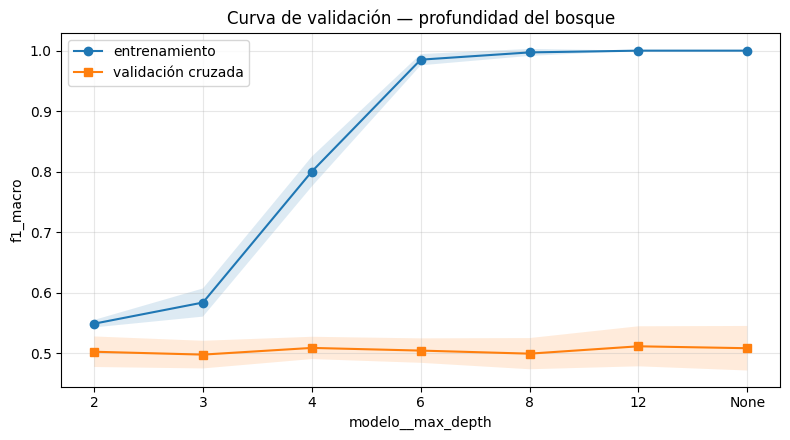

In [15]:
from act3_pipeline import curva_de_validacion

profundidades = [2, 3, 4, 6, 8, 12, None]
etiquetas = [str(p) for p in profundidades]
cv_curve = curva_de_validacion(
    construir_pipeline(), X_train, y_train, "modelo__max_depth", profundidades
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(etiquetas, cv_curve["train_media"], "o-", label="entrenamiento")
ax.fill_between(etiquetas,
                cv_curve["train_media"] - cv_curve["train_std"],
                cv_curve["train_media"] + cv_curve["train_std"], alpha=0.15)
ax.plot(etiquetas, cv_curve["test_media"], "s-", label="validación cruzada")
ax.fill_between(etiquetas,
                cv_curve["test_media"] - cv_curve["test_std"],
                cv_curve["test_media"] + cv_curve["test_std"], alpha=0.15)
ax.set_xlabel("modelo__max_depth")
ax.set_ylabel(SCORING)
ax.set_title("Curva de validación — profundidad del bosque")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La curva de entrenamiento se dispara hacia 1.0 mientras la de validación se queda plana: el modelo
tiene mucha más capacidad de la que los 115 partidos pueden sostener. Limitar la profundidad no
mejora mucho el puntaje, pero **sí reduce la brecha**, que es lo que se busca con datos escasos.

## 3.7 Selección del modelo final

Aquí hay una regla que no se puede romper: **el finalista se elige por el puntaje de validación
cruzada, nunca mirando el conjunto de prueba**. Si se eligiera por test, el test dejaría de ser una
medición independiente y volvería a ser parte del entrenamiento.

In [16]:
busquedas = {
    "GridSearchCV": grid,
    "RandomizedSearchCV": rnd,
    "HalvingGridSearchCV": halving,
}
nombre_ganador = max(busquedas, key=lambda n: busquedas[n].best_score_)
finalista = busquedas[nombre_ganador].best_estimator_

print(f"Búsqueda ganadora : {nombre_ganador}  ({SCORING} en CV = {busquedas[nombre_ganador].best_score_:.3f})")
print(f"Modelo final      : {type(finalista.named_steps['modelo']).__name__}")
print(f"Variables usadas  : k = {finalista.named_steps['seleccion'].k} de 86")
finalista

Búsqueda ganadora : RandomizedSearchCV  (f1_macro en CV = 0.619)
Modelo final      : LogisticRegression
Variables usadas  : k = 40 de 86


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('seleccion', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('porcentajes', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output 

---

# 4. Evaluation (CRISP-DM)

`best_score_` es un número optimista: es el máximo de 96 intentos sobre las mismas particiones.
Para evaluar de verdad se usan tres lentes distintos.

## 4.1 Conjunto de prueba reservado y baseline

In [17]:
from act3_pipeline import baseline, evaluar_en_prueba

mejor = finalista                     # ya reentrenado con todo el train (refit=True)
metricas = evaluar_en_prueba(mejor, X_test, y_test)
dummy = baseline(X_train, y_train, X_test, y_test)

print(f"Modelo calibrado ({nombre_ganador}):")
print(f"  accuracy={metricas['accuracy']:.3f}   f1_macro={metricas['f1_macro']:.3f}")
print(f"Baseline (clase mayoritaria):")
print(f"  accuracy={dummy['accuracy']:.3f}   f1_macro={dummy['f1_macro']:.3f}")
print()
print(metricas["reporte"])

Modelo calibrado (RandomizedSearchCV):
  accuracy=0.690   f1_macro=0.631
Baseline (clase mayoritaria):
  accuracy=0.483   f1_macro=0.217

              precision    recall  f1-score   support

    Away Win      0.714     1.000     0.833        10
        Draw      0.333     0.400     0.364         5
    Home Win      0.889     0.571     0.696        14

    accuracy                          0.690        29
   macro avg      0.646     0.657     0.631        29
weighted avg      0.733     0.690     0.686        29



### ¿La validación cruzada predijo bien el orden?

Una vez abierto el test se puede mirar hacia atrás y comprobar si el ranking de la CV se sostuvo.
Esto es **diagnóstico**, no criterio de selección: el finalista ya quedó elegido en la celda
anterior.

In [18]:
filas = []
for nombre, busqueda in busquedas.items():
    m = evaluar_en_prueba(busqueda.best_estimator_, X_test, y_test)
    filas.append({
        "búsqueda": nombre,
        "modelo": type(busqueda.best_estimator_.named_steps["modelo"]).__name__,
        f"{SCORING}_cv": busqueda.best_score_,
        f"{SCORING}_test": m["f1_macro"],
        "accuracy_test": m["accuracy"],
    })
pd.DataFrame(filas).round(3).sort_values(f"{SCORING}_cv", ascending=False)

,búsqueda,modelo,f1_macro_cv,f1_macro_test,accuracy_test
1,RandomizedSearchCV,LogisticRegression,0.619,0.631,0.690
2,HalvingGridSearchCV,RandomForestClassifier,0.594,0.562,0.655
0,GridSearchCV,RandomForestClassifier,0.563,0.605,0.655


## 4.2 Matriz de confusión

Dónde se equivoca importa más que el promedio: en este problema el error caro es confundir una
victoria local con una visitante.

                pred: Away Win  pred: Draw  pred: Home Win
real: Away Win              10           0               0
real: Draw                   2           2               1
real: Home Win               2           4               8

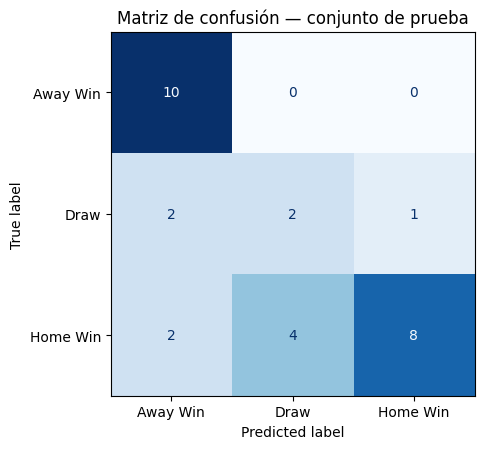

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
from act3_pipeline import matriz_confusion

print(matriz_confusion(mejor, X_test, y_test).to_string())

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ConfusionMatrixDisplay.from_estimator(
    mejor, X_test, y_test, cmap="Blues", colorbar=False, ax=ax
)
ax.set_title("Matriz de confusión — conjunto de prueba")
plt.tight_layout()
plt.show()

## 4.3 Validación cruzada anidada: la estimación honesta

Si se reporta `best_score_` se está reportando el mejor de muchos intentos sobre las mismas
particiones, y eso siempre queda por encima de la realidad. La validación cruzada **anidada**
vuelve a calibrar dentro de cada partición externa, de modo que lo que se mide es el
*procedimiento completo* (preprocesar + seleccionar + calibrar + entrenar), no un modelo con
suerte.

In [20]:
from act3_pipeline import evaluacion_anidada

anidada = evaluacion_anidada(X_train, y_train)   # rejilla reducida: 5 x 8 x 5 ajustes
print(f"CV anidada — {SCORING}: {anidada['media']:.3f} (+/- {anidada['std']:.3f})")
print("Por fold externo:", np.round(anidada["scores"], 3))
print(f"\nPara comparar, best_score_ de GridSearchCV: {grid.best_score_:.3f}")

CV anidada — f1_macro: 0.541 (+/- 0.053)
Por fold externo: [0.583 0.608 0.46  0.505 0.549]

Para comparar, best_score_ de GridSearchCV: 0.563


## 4.4 Curva de aprendizaje: ¿faltan datos?

Partidos usados  : [27 40 53 66 79 92]
f1_macro en CV   : [0.554 0.553 0.617 0.638 0.638 0.619]


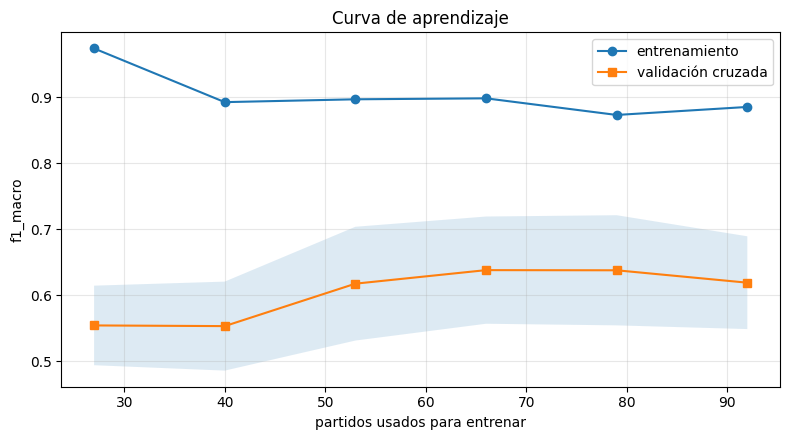

In [21]:
from act3_pipeline import curva_de_aprendizaje

lc = curva_de_aprendizaje(mejor, X_train, y_train)
print("Partidos usados  :", lc["tamanos"])
print("f1_macro en CV   :", np.round(lc["test_media"], 3))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(lc["tamanos"], lc["train_media"], "o-", label="entrenamiento")
ax.plot(lc["tamanos"], lc["test_media"], "s-", label="validación cruzada")
ax.fill_between(lc["tamanos"],
                lc["test_media"] - lc["test_std"],
                lc["test_media"] + lc["test_std"], alpha=0.15)
ax.set_xlabel("partidos usados para entrenar")
ax.set_ylabel(SCORING)
ax.set_title("Curva de aprendizaje")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La curva sube hasta los ~66 partidos y de ahí **se aplana** (la bajada del último punto está dentro
del margen de ruido). La lectura es incómoda pero útil: para este modelo, **más partidos de la
misma naturaleza ya no aportan mucho**. El techo no lo pone el tamaño del dataset ni la
calibración, sino la información que traen las variables disponibles. Para subir de verdad habría
que agregar variables **nuevas** —historial de los equipos, rachas, plantilla disponible— y no más
filas del mismo tipo.

## 4.5 ¿En qué se apoya el modelo?

,variable,importancia,std
0,home_shots_on_target,0.0595,0.0519
1,home_saves_pct,0.0489,0.0524
2,home_possession,0.0335,0.0412
3,away_saves_pct,0.0195,0.0377
4,away_shots_on_target,0.0187,0.0569
5,away_saves,0.0148,0.0441
6,away_team,0.0012,0.0112
7,away_shots_on_target_pct,-0.0021,0.0501
8,away_possession,-0.0038,0.0419
9,home_saves,-0.0075,0.0349


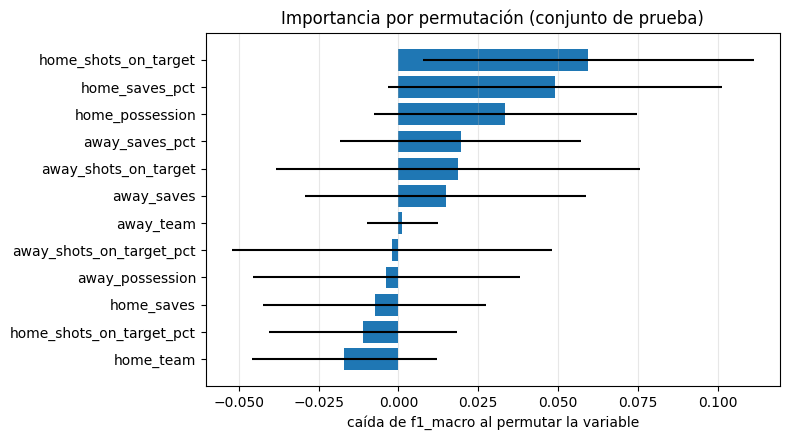

In [22]:
from act3_pipeline import importancias

imp = importancias(mejor, X_test, y_test, top=12)
display(imp.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(imp["variable"][::-1], imp["importancia"][::-1], xerr=imp["std"][::-1])
ax.set_xlabel(f"caída de {SCORING} al permutar la variable")
ax.set_title("Importancia por permutación (conjunto de prueba)")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 4.6 Resumen de la evaluación

In [23]:
resumen = pd.DataFrame(
    [
        {"medición": "Baseline (clase mayoritaria), test", "accuracy": dummy["accuracy"],
         "f1_macro": dummy["f1_macro"]},
        {"medición": "Pipeline sin calibrar, CV", "accuracy": np.nan,
         "f1_macro": base_scores.mean()},
        {"medición": "GridSearchCV best_score_, CV", "accuracy": np.nan,
         "f1_macro": grid.best_score_},
        {"medición": f"{nombre_ganador} best_score_, CV", "accuracy": np.nan,
         "f1_macro": busquedas[nombre_ganador].best_score_},
        {"medición": "CV anidada (estimación honesta)", "accuracy": np.nan,
         "f1_macro": anidada["media"]},
        {"medición": "Modelo calibrado, test reservado", "accuracy": metricas["accuracy"],
         "f1_macro": metricas["f1_macro"]},
    ]
).round(3)
resumen

,medición,accuracy,f1_macro
0,"Baseline (clase mayoritaria), test",0.483,0.217
1,"Pipeline sin calibrar, CV",NaN,0.508
2,"GridSearchCV best_score_, CV",NaN,0.563
3,"RandomizedSearchCV best_score_, CV",NaN,0.619
4,CV anidada (estimación honesta),NaN,0.541
5,"Modelo calibrado, test reservado",0.690,0.631


---

# 5. Deployment: el pipeline empaquetado

Todo lo anterior vive en el paquete `act3_pipeline`, que se instala con `pip` y trae el CSV
adentro. Un compañero solo necesita:

```bash
git clone https://github.com/DiegoLinares11/Actividad3-MLOPS.git
cd Actividad3-MLOPS
pip install .
act3-demo
```

o, si se le pasa el `.whl` por Drive o USB:

```bash
pip install act3_pipeline-0.1.0-py3-none-any.whl
act3-demo
```

El empaquetado está definido en `pyproject.toml` (metadata, dependencias, `package-data` para que
el CSV viaje dentro del wheel y el *entry point* `act3-demo`), con un `setup.py` de compatibilidad.

## 5.1 Diagrama exportado

El diagrama del pipeline también se guarda como HTML independiente para poder compartirlo sin
Jupyter:

In [24]:
from pathlib import Path
from sklearn.utils import estimator_html_repr

destino = Path("..") / "pipeline_diagram.html"
destino.write_text(estimator_html_repr(grid), encoding="utf-8")
print("Diagrama guardado en:", destino.resolve())

destino_final = Path("..") / "modelo_final_diagram.html"
destino_final.write_text(estimator_html_repr(finalista), encoding="utf-8")
print("Diagrama del modelo final guardado en:", destino_final.resolve())

Diagrama guardado en: C:\Users\dlinares\Documents\UVG\Ultimo Semestre\Machine Learning Engineering\Actividad3\pipeline_diagram.html
Diagrama del modelo final guardado en: C:\Users\dlinares\Documents\UVG\Ultimo Semestre\Machine Learning Engineering\Actividad3\modelo_final_diagram.html


## 5.2 Evidencia de ejecución en distintas computadoras

Como todas las semillas están fijas (`random_state=42` en la partición, en la validación cruzada y
en los modelos), **el resultado debe ser idéntico en cualquier máquina**. La celda siguiente
imprime la identidad del equipo junto con las métricas: esa es la captura que se toma en cada
computadora.

In [25]:
print("=" * 64)
print("EVIDENCIA DE EJECUCIÓN — Actividad 3")
print("=" * 64)
print(f"Equipo (hostname) : {socket.gethostname()}")
print(f"Sistema operativo : {platform.system()} {platform.release()}")
print(f"Python            : {platform.python_version()}")
print(f"scikit-learn      : {sklearn.__version__}")
print("-" * 64)
print(f"Busqueda ganadora    : {nombre_ganador}")
print(f"Modelo final         : {type(finalista.named_steps['modelo']).__name__}")
print(f"Mejor {SCORING} en CV : {busquedas[nombre_ganador].best_score_:.3f}")
print(f"Test  accuracy       : {metricas['accuracy']:.3f}")
print(f"Test  f1_macro       : {metricas['f1_macro']:.3f}")
print("=" * 64)

EVIDENCIA DE EJECUCIÓN — Actividad 3
Equipo (hostname) : Dlinares
Sistema operativo : Windows 11
Python            : 3.14.2
scikit-learn      : 1.8.0
----------------------------------------------------------------
Busqueda ganadora    : RandomizedSearchCV
Modelo final         : LogisticRegression
Mejor f1_macro en CV : 0.619
Test  accuracy       : 0.690
Test  f1_macro       : 0.631


Las capturas están en `docs/screenshots/` y la tabla comparativa, en el README del repositorio.

---

# 6. Conclusiones

1. **Calibrar sirvió, y se puede decir exactamente por qué.** El `f1_macro` en validación cruzada
   subió de **0.508** (pipeline con valores por defecto) a **0.619** (mejor combinación
   encontrada), y en el conjunto de prueba el modelo final llega a **0.631** de `f1_macro` y
   **0.690** de accuracy, contra **0.217** y **0.483** del baseline. El mérito no está repartido
   parejo: el análisis de la sección 3.3 muestra que casi todo viene de `class_weight="balanced"`
   y de recortar variables con `seleccion__k`, mientras que `n_estimators` y la estrategia de
   imputación resultaron irrelevantes.

2. **Saber qué hiperparámetro *no* importa vale tanto como saber cuál sí.** Confirmar con datos que
   `n_estimators=200` iguala a 400 permite quedarse con el modelo barato sin perder nada, y
   descartar la rejilla de imputación en futuras búsquedas. Calibrar no es solo encontrar el
   máximo: es entender la superficie.

3. **La búsqueda aleatoria le ganó a la exhaustiva, y en una fracción del tiempo** (0.619 en ~6 s
   contra 0.563 en ~47 s). No es magia: `GridSearchCV` estaba encerrado en un solo vecindario
   —Random Forest— mientras que `RandomizedSearchCV` podía cambiar de familia de modelo, y una
   regresión logística regularizada resultó más adecuada para 115 filas con 86 columnas que un
   bosque. Con datasets chicos, **el modelo más simple suele ser el correcto**, y esa conclusión
   solo aparece si se lo deja competir.

4. **Optimizar `f1_macro` en lugar de `accuracy` cambia el modelo que gana.** Con `accuracy` la
   búsqueda se queda con un modelo que casi nunca predice empate (es la estrategia rentable cuando
   solo se cuentan aciertos). Con `f1_macro` y `class_weight="balanced"` el modelo pierde algo de
   accuracy pero **detecta empates**, que es lo que hace útil al clasificador. La métrica es una
   decisión de negocio, no un detalle técnico.

5. **El pipeline es lo que hace válida la calibración.** Al meter imputación, escalado, One-Hot y
   selección de variables dentro del `Pipeline`, la búsqueda los reajusta en cada fold. Hacer ese
   preprocesamiento antes de partir los datos habría filtrado información y habría dado un puntaje
   inflado.

6. **`best_score_` no es la métrica que se reporta.** Es el máximo de decenas de intentos sobre las
   mismas particiones. La validación cruzada anidada (**0.541**) queda por debajo del `best_score_`
   de la rejilla (**0.563**), y esa diferencia es exactamente el optimismo que introduce la propia
   búsqueda.

7. **El modelo ignora quién juega.** La importancia por permutación deja a `home_team` y
   `away_team` en **prácticamente cero** (incluso negativa): las 72 columnas del One-Hot no aportan
   nada y solo estorbaban, lo mismo que ya había insinuado el `seleccion__k` recortado. Lo que
   decide son los tiros a puerta y las atajadas del equipo local.

8. **La validación cruzada acertó el orden.** El modelo que ganó en CV también fue el mejor en el
   conjunto de prueba (`f1_macro` 0.631 contra 0.605 y 0.562 de los otros dos). No estaba
   garantizado —con 29 partidos de prueba el ranking pudo haberse volteado— pero es la señal de
   que el procedimiento de selección funcionó.

## Limitaciones

- **29 partidos de prueba.** Cada acierto vale 3.4 puntos de accuracy, así que las métricas traen
  un margen de error amplio.
- **Los empates siguen siendo el punto débil**: 25 ejemplos en total y sin una huella estadística
  clara que los distinga.
- **Las variables se conocen cuando el partido ya terminó** (posesión, tiros, atajadas), así que el
  modelo *explica* el resultado más de lo que lo *predice*. Para un pronóstico previo harían falta
  variables históricas de cada equipo.
- La ventaja del `HalvingGridSearchCV` se ve poco con 115 filas; su beneficio aparece con datasets
  grandes.